In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from enums.Dataset import Dataset
from model.XGBoostModel import XGBoostModel
from utils import utils

dataset = Dataset.NURSE

In [3]:
df = utils.load_data(dataset=dataset, which="all", with_features=True)

In [5]:
import shap
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder

# ---- Setup your data ----
# df: your full dataframe
# features: list of feature column names
# label: name of target column
# subject_col: name of subject ID column

features = [col for col in df.columns if col not in ['Label', 'Participant']]
X = df[features].values
y = df['Label'].values
groups = df['Participant'].values

# Leave-One-Subject-Out CV
logo = LeaveOneGroupOut()

# Store mean absolute SHAP values for each feature across folds
shap_values_list = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, y_train = X[train_idx], y[train_idx]

    # Train XGBoost model
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)

    # Compute SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)

    # Take mean absolute SHAP values per feature
    shap_mean = np.abs(shap_values).mean(axis=0)
    shap_values_list.append(shap_mean)

# ---- Aggregate SHAP values across folds ----
mean_shap_importance = np.mean(shap_values_list, axis=0)

# Create a DataFrame for easy handling
feature_importance_df = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': mean_shap_importance
})

# Sort by importance
feature_importance_df.sort_values(by='mean_abs_shap', ascending=False, inplace=True)

# ---- Select top N features ----
# Keep top 50% most important features
n_top = len(features) // 2
top_features = feature_importance_df.head(n_top)['feature'].tolist()

# Filter your dataframe to keep only those features
df_reduced = df[top_features + ['Label', 'Participant']]

/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:31:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:33:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:34:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:36:34] WARNING: /Users/runner/work/xgboost/xgboost/src/

In [6]:
df_reduced.head()

,EDA_min,TEMP_max,EDA_median,EDA_max,TEMP_min,HR_min,Deriv_EDA_abs_dev,ACC_Y_rms,EDA_mean,TEMP_median,...,Deriv_2_ACC_Z_kurtosis,Wavelet_1Hz_ACC_X_kurtosis,Deriv_ACC_X_range,Wavelet_2Hz_ACC_Y_kurtosis,Wavelet_1Hz_ACC_Y_skew,Deriv_2_HR_max_amp,Deriv_HR_var,Deriv_2_EDA_range,Label,Participant
0,0.037163,32.87,3.718497,4.206416,32.29,67.97,0.013376,10.825534,3.345934,32.45,...,12.943355,8.524188,70.0,11.647937,0.273222,0.53,0.000564,1.104778,1.0,15
1,0.053822,32.89,3.723296,4.206416,32.29,67.97,0.013376,10.832099,3.362750,32.45,...,12.953252,8.522005,70.0,11.621053,0.272828,0.53,0.000598,1.104778,1.0,15
2,0.053822,32.89,3.726500,4.206416,32.29,67.97,0.013366,10.839934,3.379433,32.45,...,12.947256,8.519315,70.0,11.611912,0.273686,0.53,0.000598,1.104778,1.0,15
3,0.053822,32.89,3.730344,4.241016,32.29,67.97,0.013422,10.846538,3.396661,32.45,...,12.934540,8.518769,70.0,11.584869,0.273254,0.53,0.000598,1.104778,1.0,15
4,0.543617,32.89,3.734189,4.348660,32.29,67.97,0.013202,10.851435,3.414556,32.45,...,12.936174,8.518242,70.0,11.575954,0.273254,0.53,0.000579,1.104778,1.0,15


In [8]:
# Save the dataset
df_reduced.to_pickle("../../datasets/nurse/processed/with_features/reduced/all.pkl")

for participant in df_reduced["Participant"].unique():
    participant_data = df_reduced[df_reduced["Participant"] == participant]
    participant_data.to_pickle(f"../../datasets/nurse/processed/with_features/reduced/{participant}.pkl")

<Figure size 4000x2000 with 0 Axes>

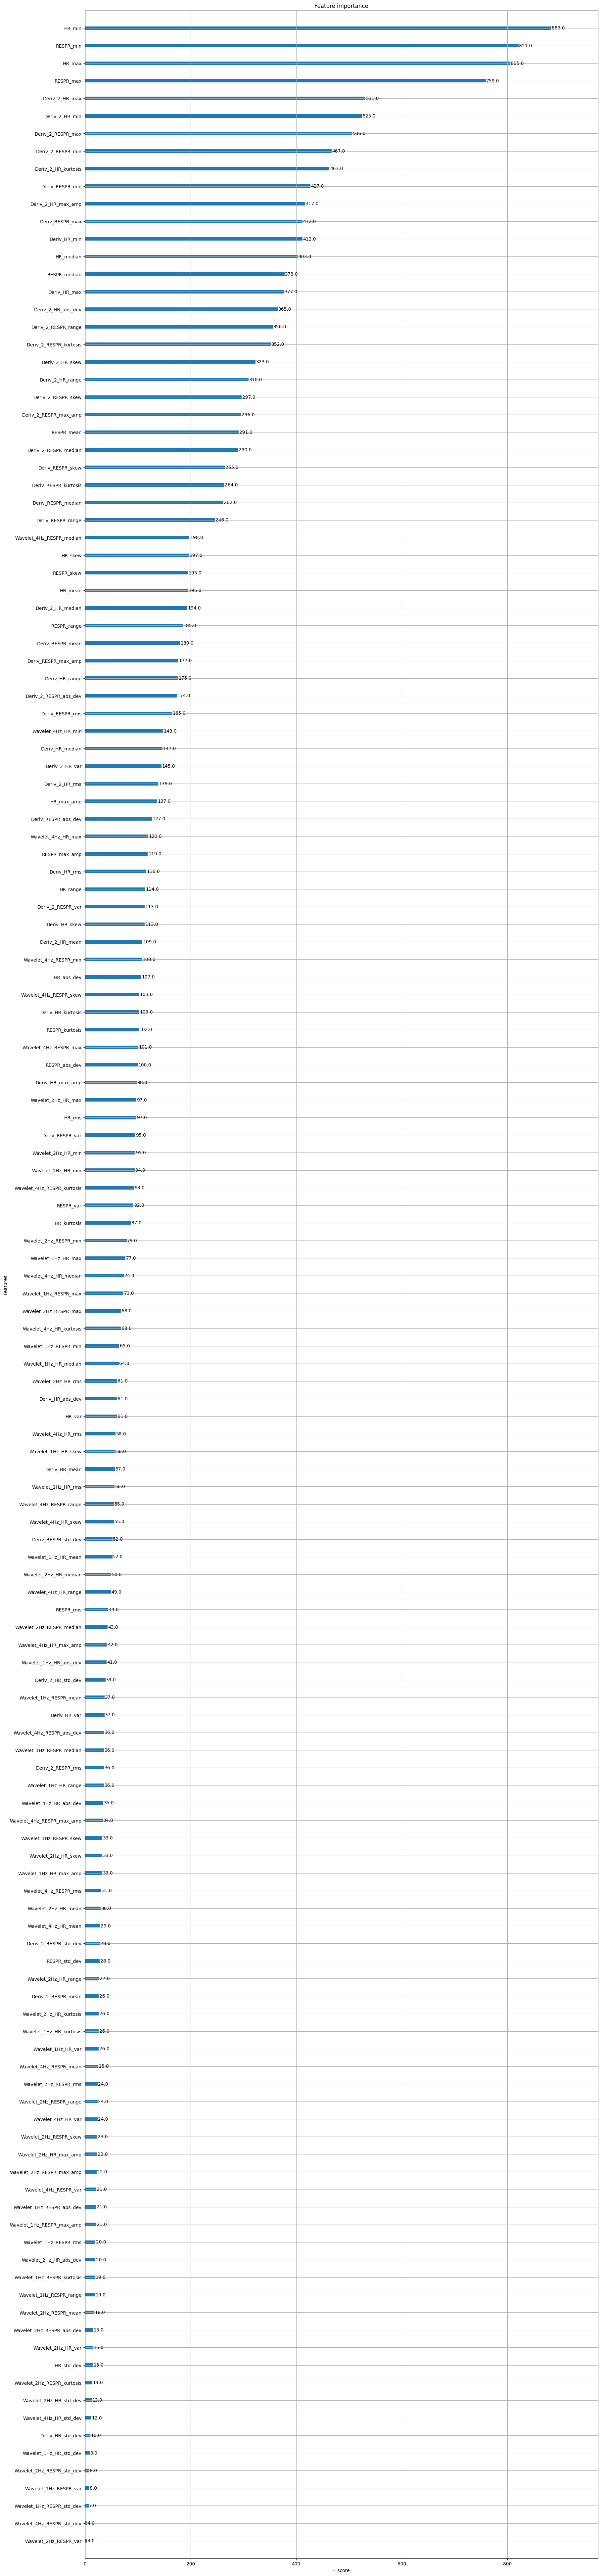

In [19]:
from xgboost import plot_importance

plt.figure(figsize=(40,20))
plot_importance(model.get_fitted_model().named_steps["clf"])
plt.show()